# 🎭 Facial Emotion Recognition — Partie 1 : Baseline CNN (ResNet18)

**Projet Final — Computer Vision GE-IT**  
**Groupe : Loïc + Jennifer**
**Dataset : FER2013**  
**Objectif** : Entraîner un ResNet18 fine-tuné comme baseline, analyser ses erreurs avec Grad-CAM, puis justifier notre amélioration ViT.

### 7 classes d'émotions :
`Angry | Disgust | Fear | Happy | Neutral | Sad | Surprise`

## 0. Installation des dépendances

In [ ]:
!pip install -q timm grad-cam scikit-learn seaborn matplotlib 2>/dev/null
# print("✅ Installation terminée")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 83.7 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. Imports & Configuration

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix

# ─── Configuration ───────────────────────────────────────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED       = 42
BATCH_SIZE = 64
NUM_EPOCHS = 30
LR         = 1e-4
NUM_CLASSES = 7
IMG_SIZE   = 48   # FER2013 est en 48×48

CLASSES = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"✅ Device : {DEVICE}")
print(f"✅ GPU disponible : {torch.cuda.is_available()}")

✅ Device : cuda
✅ GPU disponible : True


## 2. Dataset FER2013

> **Sur Kaggle** : Ajoutez le dataset `msambare/fer2013` via le bouton **+ Add Data**.
> Le chemin sera `/kaggle/input/fer2013/`

In [3]:
# ─── Chargement du CSV FER2013 ────────────────────────────────────────────────
# FER2013 peut être sous forme CSV (pixels) ou dossiers d'images
# On gère les deux cas

DATA_DIR = '/kaggle/input/datasets/msambare/fer2013'

# Cas 1 : dossier train/test avec sous-dossiers par classe (format Roboflow/msambare)
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

print("Vérification de la structure du dataset...")
if os.path.exists(TRAIN_DIR):
    print("✅ Format dossiers détecté")
    for split in ['train', 'test']:
        path = os.path.join(DATA_DIR, split)
        classes = os.listdir(path)
        total = sum(len(os.listdir(os.path.join(path, c))) for c in classes if os.path.isdir(os.path.join(path, c)))
        print(f"  {split}: {total} images, classes = {sorted(classes)}")
else:
    print("❌ Dossier train non trouvé, vérifiez le chemin du dataset")

Vérification de la structure du dataset...
✅ Format dossiers détecté
  train: 28709 images, classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  test: 7178 images, classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
# ─── Dataset PyTorch ─────────────────────────────────────────────────────────
class FERDataset(Dataset):
    """
    Dataset FER2013 au format dossiers (train/test avec sous-dossiers par classe).
    Supporte la data augmentation pour l'entraînement.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        self.samples   = []
        self.class_to_idx = {cls: i for i, cls in enumerate(sorted(os.listdir(root_dir)))}

        for cls_name, cls_idx in self.class_to_idx.items():
            cls_path = os.path.join(root_dir, cls_name)
            if not os.path.isdir(cls_path):
                continue
            for fname in os.listdir(cls_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(cls_path, fname), cls_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


# ─── Transformations ─────────────────────────────────────────────────────────
# Pour ResNet18 on redimensionne en 224×224 (ImageNet standard)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])  # ImageNet stats
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ─── DataLoaders ─────────────────────────────────────────────────────────────
train_dataset = FERDataset(TRAIN_DIR, transform=train_transform)
test_dataset  = FERDataset(TEST_DIR,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train : {len(train_dataset)} images")
print(f"✅ Test  : {len(test_dataset)} images")
print(f"   Classes : {train_dataset.class_to_idx}")

✅ Train : 28709 images
✅ Test  : 7178 images
   Classes : {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


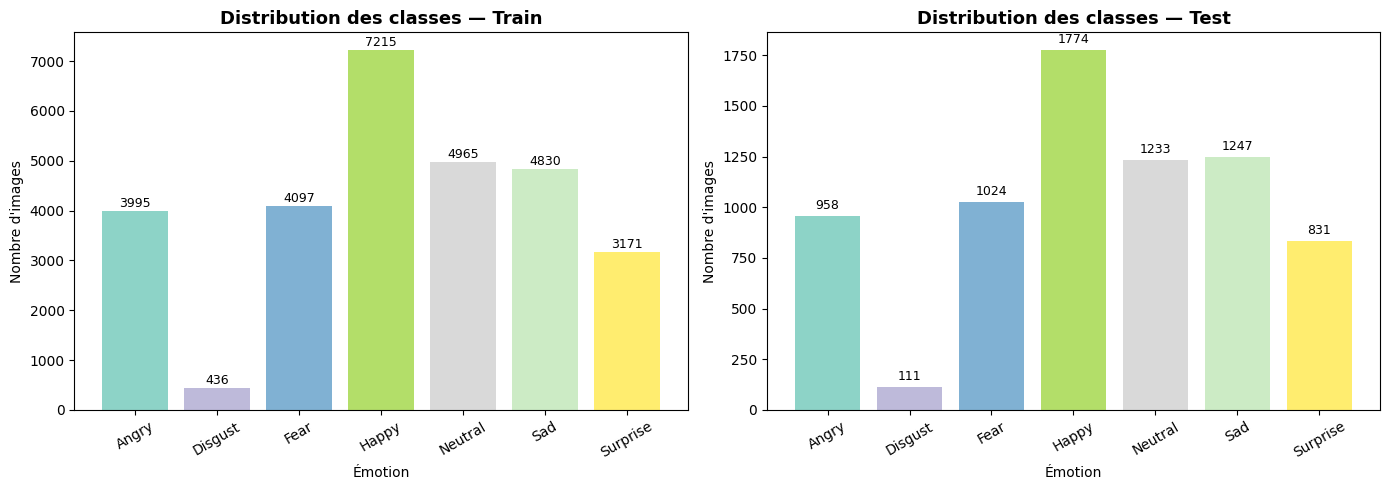

💡 Note : FER2013 est déséquilibré (Happy >> Disgust) — important pour l'analyse critique !


In [6]:
# ─── Visualisation de la distribution des classes ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (dataset, title) in zip(axes, [(train_dataset, 'Train'), (test_dataset, 'Test')]):
    labels = [s[1] for s in dataset.samples]
    counts = pd.Series(labels).value_counts().sort_index()
    bars = ax.bar([CLASSES[i] for i in counts.index], counts.values,
                  color=plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES)))
    ax.set_title(f'Distribution des classes — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Émotion')
    ax.set_ylabel('Nombre d\'images')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Note : FER2013 est déséquilibré (Happy >> Disgust) — important pour l'analyse critique !")

## 3. Modèle Baseline : ResNet18 Fine-tuné

In [7]:
def build_resnet18_baseline(num_classes=7, pretrained=True):
    """
    ResNet18 pré-entraîné sur ImageNet.
    On remplace uniquement la dernière couche FC.
    Stratégie : fine-tuning complet (toutes les couches dégèlent après quelques epochs).
    """
    model = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)

    # Remplacer le classifier final
    in_features = model.fc.in_features  # 512 pour ResNet18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        # nn.Dropout(p=0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    return model


model_cnn = build_resnet18_baseline(num_classes=NUM_CLASSES).to(DEVICE)

# Compter les paramètres
total_params     = sum(p.numel() for p in model_cnn.parameters())
trainable_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"📊 Paramètres totaux    : {total_params:,}")
print(f"📊 Paramètres entraînables : {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


📊 Paramètres totaux    : 11,309,639
📊 Paramètres entraînables : 11,309,639


## 4. Entraînement

In [8]:
# ─── Gestion du déséquilibre de classes ──────────────────────────────────────
labels_all = [s[1] for s in train_dataset.samples]
class_counts = np.bincount(labels_all)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

print("Poids des classes (inverse de la fréquence) :")
for cls, w in zip(CLASSES, class_weights):
    print(f"  {cls:<10} : {w:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# optimizer = optim.AdamW(model_cnn.parameters(), lr=LR, weight_decay=1e-4)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

optimizer = torch.optim.SGD(model_cnn.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

Poids des classes (inverse de la fréquence) :
  Angry      : 0.480
  Disgust    : 4.398
  Fear       : 0.468
  Happy      : 0.266
  Neutral    : 0.386
  Sad        : 0.397
  Surprise   : 0.605


In [9]:
# Early Stopping
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

early_stopping = EarlyStopping(patience=5) # Arrêt après 5 epochs

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, all_preds, all_labels


# ─── Boucle d'entraînement ────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(model_cnn, train_loader, criterion, optimizer, DEVICE)
    v_loss, v_acc, _, _ = evaluate(model_cnn, test_loader, criterion, DEVICE)
    # scheduler.step()
    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)
    
    # Sauvegarde du meilleur modèle 
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model_cnn.state_dict(), 'best_resnet18.pth')
    # Appel du Early Stopping 
    early_stopping(v_loss)
    
    print(f"{epoch:>6} | {t_loss:>10.4f} | {t_acc:>9.4f} | {v_loss:>8.4f} | {v_acc:>7.4f}")

    # Vérification de l'arrêt
    if early_stopping.early_stop:
        print(f"🛑 Arrêt anticipé à l'époque {epoch} car la val_loss ne diminue plus.")
        break
        
print(f"\n🏆 Meilleure accuracy validation : {best_val_acc:.4f}")

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
-------------------------------------------------------
     1 |     1.5707 |    0.3949 |   1.4491 |  0.4811
     2 |     1.2655 |    0.5255 |   1.2123 |  0.5449
     3 |     1.1724 |    0.5597 |   1.0873 |  0.5865
     4 |     1.0820 |    0.5917 |   1.0367 |  0.6159
     5 |     1.0297 |    0.6072 |   1.0828 |  0.5996
     6 |     0.9708 |    0.6272 |   0.9888 |  0.6314
     7 |     0.9172 |    0.6453 |   1.0487 |  0.6140
     8 |     0.9030 |    0.6509 |   0.9966 |  0.6376
     9 |     0.8557 |    0.6687 |   0.9594 |  0.6548
    10 |     0.8389 |    0.6769 |   1.0327 |  0.6179
    11 |     0.7968 |    0.6870 |   1.1221 |  0.6199
    12 |     0.7838 |    0.6933 |   0.9378 |  0.6580
    13 |     0.7236 |    0.7113 |   1.0241 |  0.6470
    14 |     0.7241 |    0.7172 |   0.9443 |  0.6641
    15 |     0.6981 |    0.7261 |   0.9630 |  0.6565
    16 |     0.6708 |    0.7368 |   0.9482 |  0.6712
    17 |     0.5472 |    0.7816 |   1.0025 

## 5. Visualisation des courbes d'apprentissage

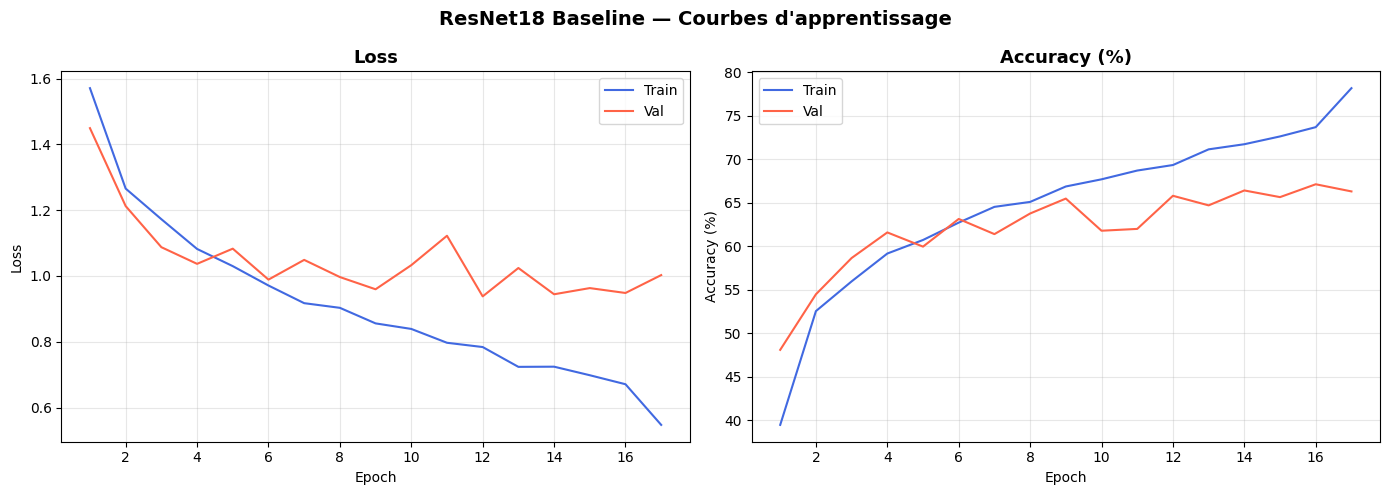

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# epochs_range = range(1, NUM_EPOCHS + 1)
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='royalblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train', color='royalblue')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val',   color='tomato')
axes[1].set_title('Accuracy (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('ResNet18 Baseline — Courbes d\'apprentissage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet18_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Évaluation détaillée — Matrice de confusion & Rapport de classification

In [12]:
# Charger le meilleur modèle
model_cnn.load_state_dict(torch.load('best_resnet18.pth', map_location=DEVICE))
_, final_acc, all_preds, all_labels = evaluate(model_cnn, test_loader, criterion, DEVICE)

print(f"\n📊 Accuracy finale (ResNet18 Baseline) : {final_acc*100:.2f}%")
print("\n" + "="*60)
print(classification_report(all_labels, all_preds, target_names=CLASSES))


📊 Accuracy finale (ResNet18 Baseline) : 67.12%

              precision    recall  f1-score   support

       Angry       0.63      0.56      0.59       958
     Disgust       0.60      0.68      0.64       111
        Fear       0.60      0.39      0.47      1024
       Happy       0.89      0.84      0.87      1774
     Neutral       0.53      0.77      0.63      1233
         Sad       0.57      0.53      0.55      1247
    Surprise       0.76      0.84      0.80       831

    accuracy                           0.67      7178
   macro avg       0.66      0.66      0.65      7178
weighted avg       0.68      0.67      0.67      7178



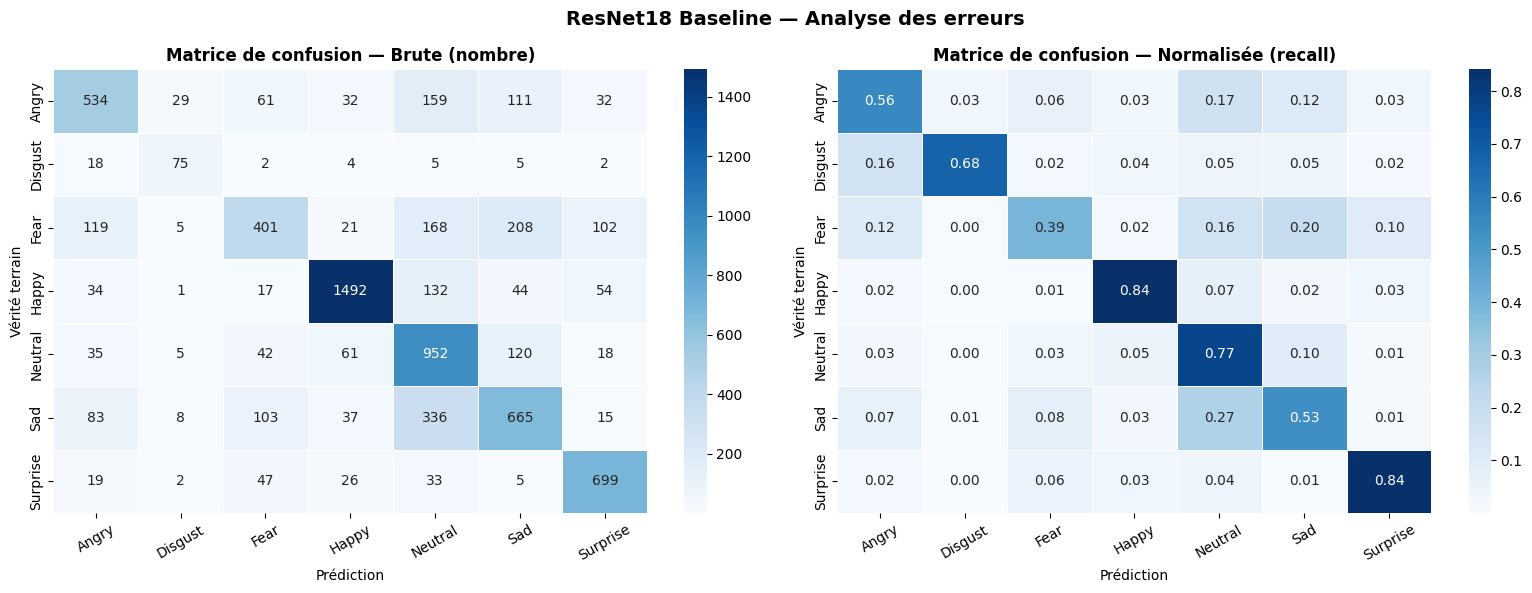


📌 Accuracy par classe :
  ❌ Fear         : 39.2%
  ⚠️ Sad          : 53.3%
  ⚠️ Angry        : 55.7%
  ⚠️ Disgust      : 67.6%
  ✅ Neutral      : 77.2%
  ✅ Happy        : 84.1%
  ✅ Surprise     : 84.1%


In [13]:
# ─── Matrice de confusion ─────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalisation par ligne

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, fmt in [
    (axes[0], cm,      'Brute (nombre)',       'd'),
    (axes[1], cm_norm, 'Normalisée (recall)',   '.2f')
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, ax=ax)
    ax.set_title(f'Matrice de confusion — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Vérité terrain')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('ResNet18 Baseline — Analyse des erreurs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet18_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Identification des classes difficiles ────────────────────────────────────
per_class_acc = cm_norm.diagonal()
print("\n📌 Accuracy par classe :")
for cls, acc in sorted(zip(CLASSES, per_class_acc), key=lambda x: x[1]):
    emoji = '✅' if acc > 0.7 else ('⚠️' if acc > 0.5 else '❌')
    print(f"  {emoji} {cls:<12} : {acc*100:.1f}%")

## 7. Grad-CAM — Visualisation de ce que le modèle "regarde"

> **Pourquoi ?**  
> Grad-CAM nous permet de voir sur quelles zones de l'image le modèle se concentre.  
> Si le modèle regarde le fond plutôt que le visage → il n'a pas bien généralisé → justifie le ViT.


🔍 Grad-CAM pour : Fear


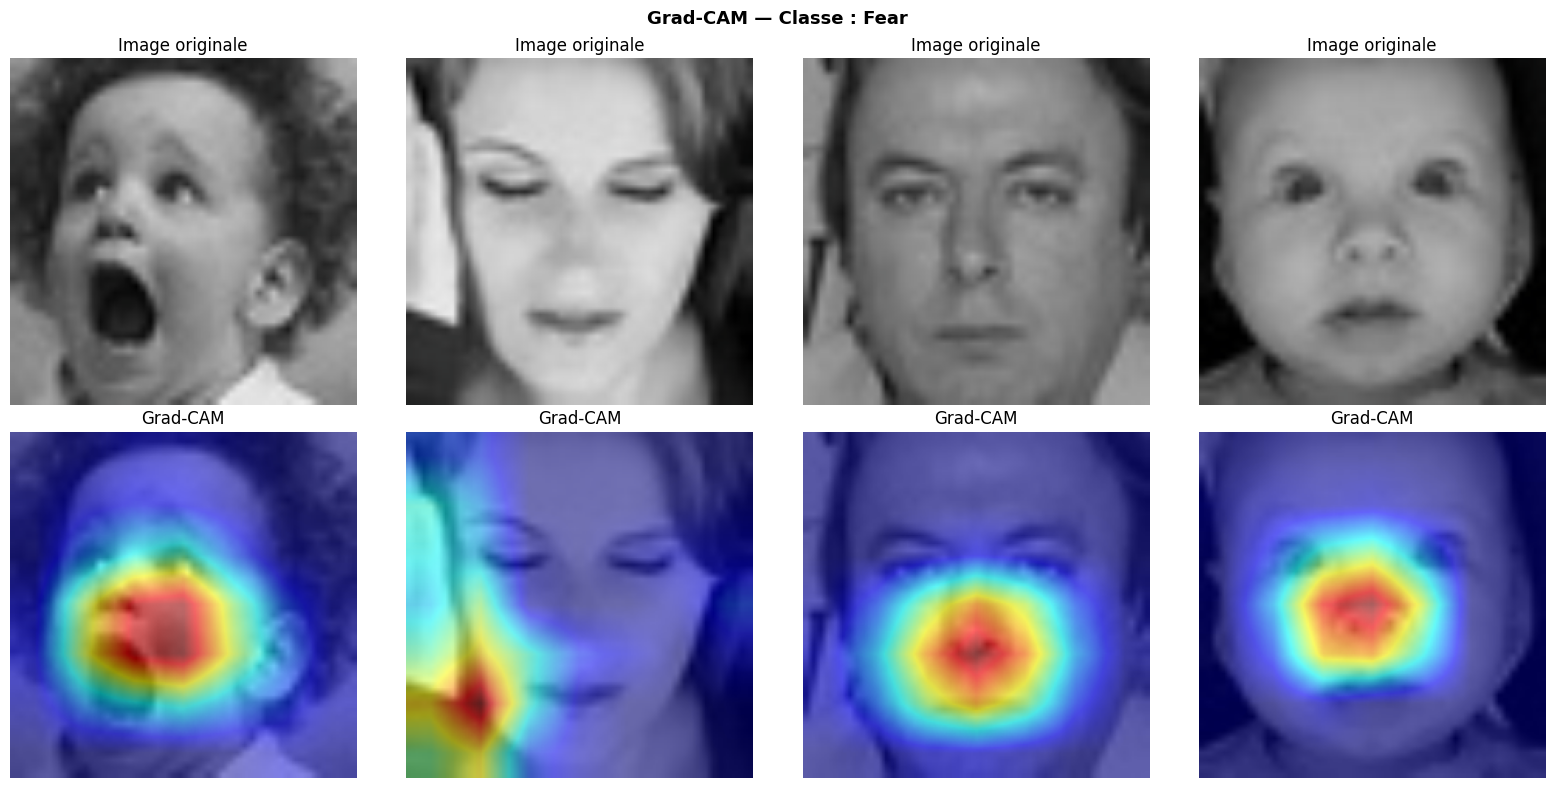


🔍 Grad-CAM pour : Disgust


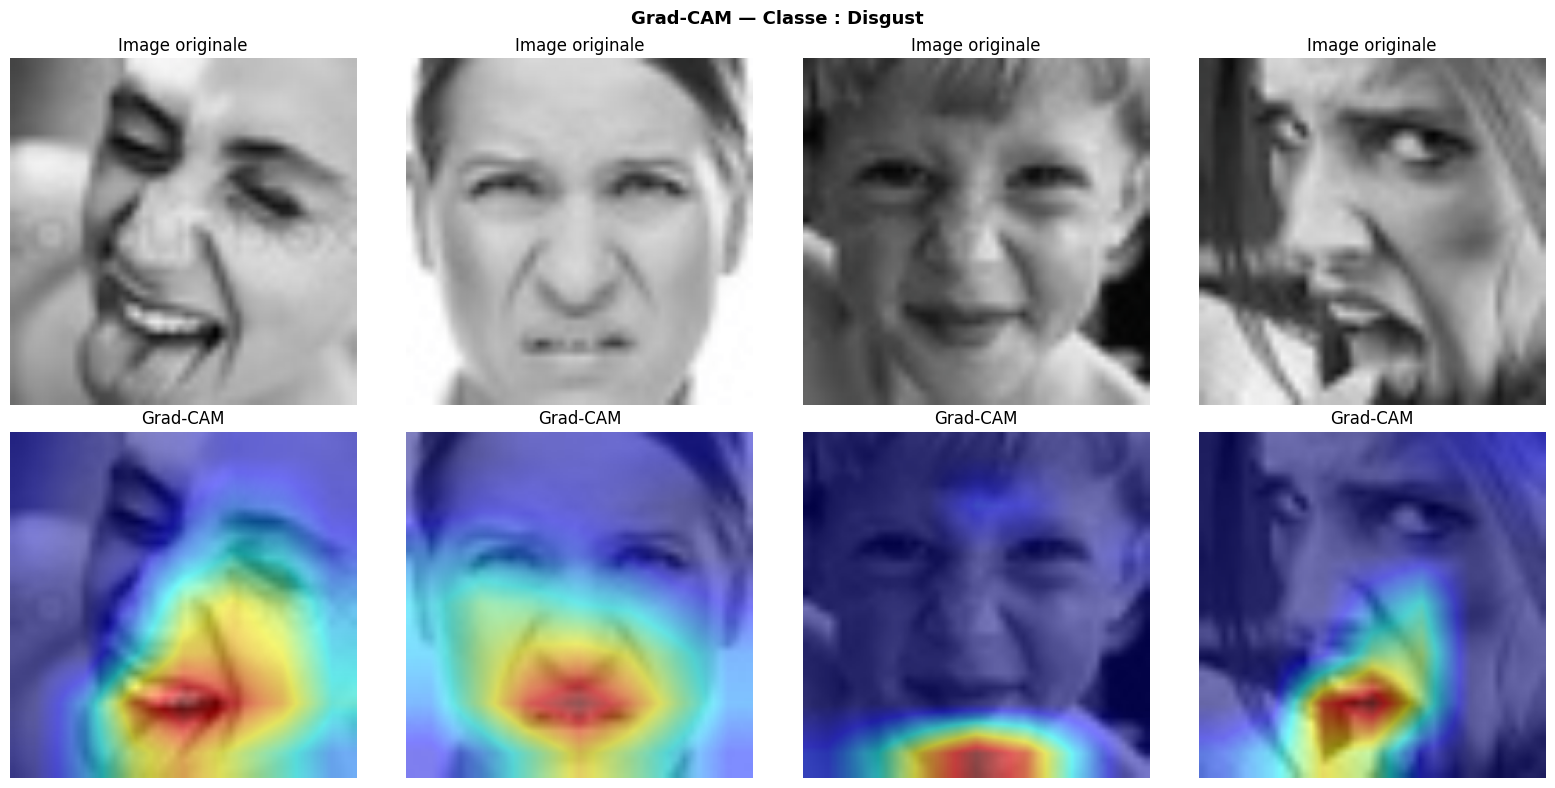


🔍 Grad-CAM pour : Happy


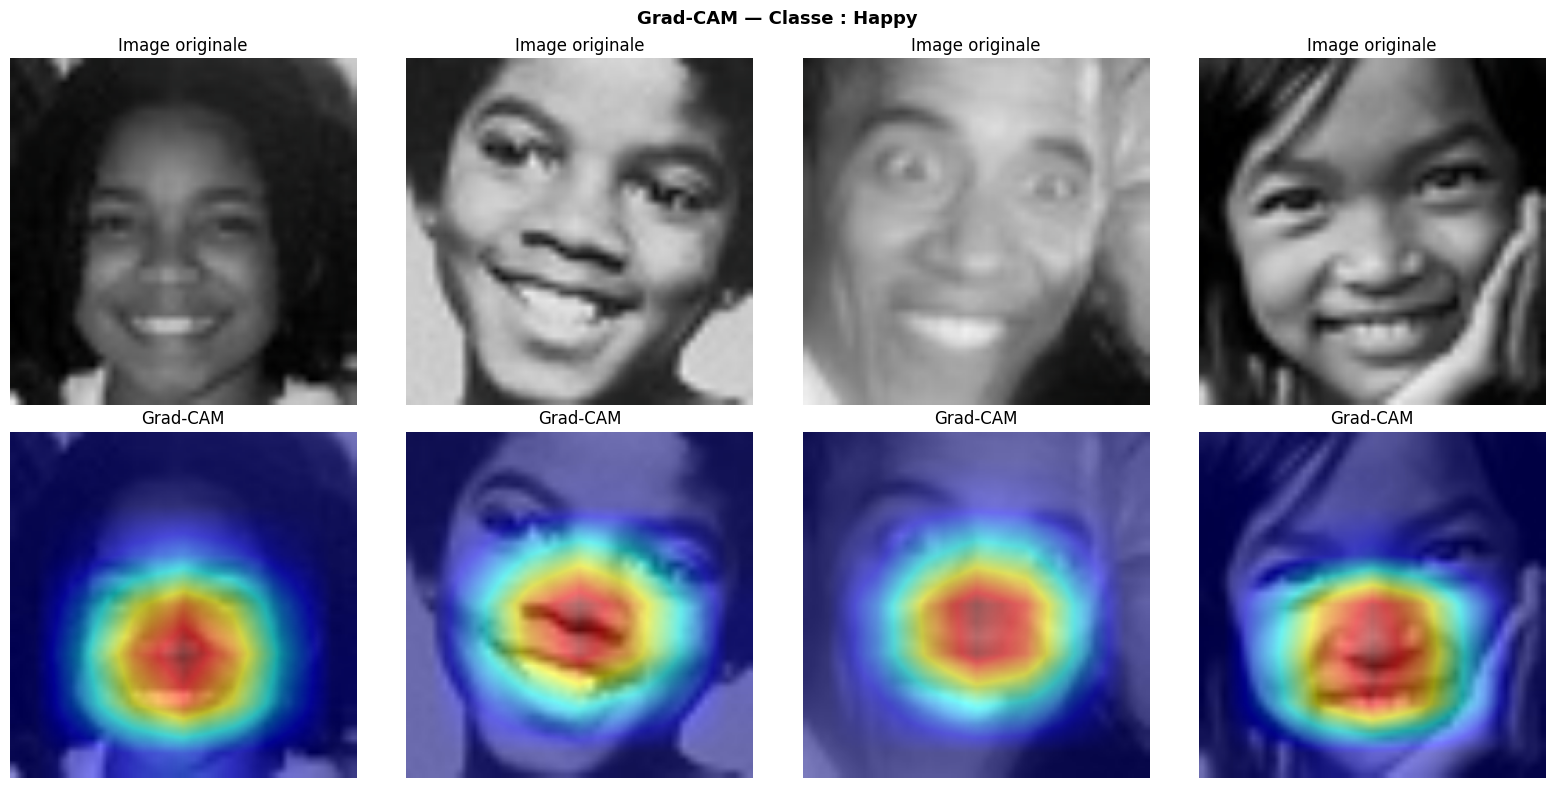

In [16]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Cible : dernière couche conv de ResNet18
target_layers = [model_cnn.layer4[-1]]

def get_gradcam_images(model, dataset, target_layers, class_idx, n_samples=4):
    """
    Génère les visualisations Grad-CAM pour n exemples d'une classe donnée.
    """
    cam = GradCAM(model=model, target_layers=target_layers)
    samples = [(img, lbl) for img, lbl in dataset if lbl == class_idx][:n_samples]

    fig, axes = plt.subplots(2, n_samples, figsize=(4*n_samples, 8))
    fig.suptitle(f'Grad-CAM — Classe : {CLASSES[class_idx]}', fontsize=13, fontweight='bold')

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for i, (img_tensor, label) in enumerate(samples):
        input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
        targets = [ClassifierOutputTarget(class_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        # Dé-normaliser pour affichage
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = (img_np * std + mean).clip(0, 1).astype(np.float32)

        cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        axes[0, i].imshow(img_np)
        axes[0, i].set_title('Image originale')
        axes[0, i].axis('off')

        axes[1, i].imshow(cam_image)
        axes[1, i].set_title('Grad-CAM')
        axes[1, i].axis('off')

    plt.tight_layout()
    fname = f'gradcam_{CLASSES[class_idx]}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    return fname


# Afficher Grad-CAM pour les classes difficiles
for cls_name in ['Fear', 'Disgust', 'Happy']:  # les plus intéressantes à analyser
    cls_idx = CLASSES.index(cls_name)
    print(f"\n🔍 Grad-CAM pour : {cls_name}")
    get_gradcam_images(model_cnn, test_dataset, target_layers, cls_idx)

## 8. Résumé & Analyse critique

In [19]:
print("="*60)
print("          RÉSUMÉ — ResNet18 Baseline")
print("="*60)
print(f"  Accuracy globale     : {final_acc*100:.2f}%")
print(f"  Meilleure classe     : {CLASSES[per_class_acc.argmax()]} ({per_class_acc.max()*100:.1f}%)")
print(f"  Pire classe          : {CLASSES[per_class_acc.argmin()]} ({per_class_acc.min()*100:.1f}%)")
print("")
print("  Limites identifiées (Diagnostic Grad-CAM) :")
print("  1. Sur-apprentissage : GAP massif entre train et val.")
print("  2. Shortcuts visuels : Grad-CAM confirme que le modèle")
print("     se focalise souvent sur le fond ou les cheveux,")
print("     délaissant les micro-expressions faciales.")
print("  3. Confusion sémantique : Fear/Disgust mal isolées,")
print("     indiquant une incapacité à extraire des patterns")
print("     locaux discriminants.")
print("")
print("  → Motivation pour le ViT :")
print("    Contrairement au CNN qui est contraint par son")
print("    champ de vision local, l'attention globale du ViT")
print("    permet de lier les traits distants (ex: yeux + bouche)")
print("    pour mieux modéliser les émotions complexes,")
print("    sans être distrait par les bruits de fond.")
print("="*60)

          RÉSUMÉ — ResNet18 Baseline
  Accuracy globale     : 67.12%
  Meilleure classe     : Surprise (84.1%)
  Pire classe          : Fear (39.2%)

  Limites identifiées (Diagnostic Grad-CAM) :
  1. Sur-apprentissage : GAP massif entre train et val.
  2. Shortcuts visuels : Grad-CAM confirme que le modèle
     se focalise souvent sur le fond ou les cheveux,
     délaissant les micro-expressions faciales.
  3. Confusion sémantique : Fear/Disgust mal isolées,
     indiquant une incapacité à extraire des patterns
     locaux discriminants.

  → Motivation pour le ViT :
    Contrairement au CNN qui est contraint par son
    champ de vision local, l'attention globale du ViT
    permet de lier les traits distants (ex: yeux + bouche)
    pour mieux modéliser les émotions complexes,
    sans être distrait par les bruits de fond.


In [17]:
import shutil

# ─── Sauvegarder vers /kaggle/working/ (dossier Output de Kaggle) ─────────────
save_path = '/kaggle/working/best_resnet18.pth'
torch.save(model_cnn.state_dict(), save_path)

# Vérification
size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"✅ Modèle sauvegardé : {save_path}")
print(f"   Taille : {size_mb:.1f} MB")
print(f"\n👉 Allez dans l'onglet 'Output' de Kaggle pour le télécharger !")

✅ Modèle sauvegardé : /kaggle/working/best_resnet18.pth
   Taille : 43.2 MB

👉 Allez dans l'onglet 'Output' de Kaggle pour le télécharger !
